# MDN — Mixture Density Network for SWH Forecasting

In [1]:
# ── Cell 1: Environment ──────────────────────────────────────
RUN_ENV  = 'local'
BASE_DIR = r'c:\Users\DA IICT K\Desktop\BMP_files\SWH_codes'         # change to your path
if RUN_ENV == 'colab':
    from google.colab import drive; drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/BMP_Data/'

import os, warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.preprocessing import RobustScaler
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

# ── SWH-specific paths (only change from SLA notebooks) ──────
DATA_FILE = os.path.join(BASE_DIR, 'swh_daily_indian_ocean_2021_2023.nc')
SAVE_DIR  = os.path.join(BASE_DIR, 'results_SWH/')
os.makedirs(SAVE_DIR, exist_ok=True)

print(f'TF {tf.__version__} | Env: {RUN_ENV}')
print(f'Data: {DATA_FILE}')
print(f'Save: {SAVE_DIR}')

from sklearn.neighbors import KernelDensity

TF 2.21.0 | Env: local
Data: c:\Users\DA IICT K\Desktop\BMP_files\SWH_codes\swh_daily_indian_ocean_2021_2023.nc
Save: c:\Users\DA IICT K\Desktop\BMP_files\SWH_codes\results_SWH/


Loading SWH dataset...
SWH variable detected: VHM0
Period: 2021-01-01 to 2023-12-31 (1095 days)
Grid: lat=-9.80 to 24.80, lon=50.20 to 100.00

Coverage check at each location:
  Arabian_Sea        (15.0N,65.0E) | NaN=0.0% | range=[0.587, 6.220]m ✓
  Bay_of_Bengal      (12.0N,87.0E) | NaN=0.0% | range=[0.699, 4.966]m ✓
  Andaman_Sea        (11.0N,95.0E) | NaN=0.0% | range=[0.466, 3.289]m ✓
  Lakshadweep        (10.0N,73.0E) | NaN=0.0% | range=[0.651, 4.692]m ✓
  South_IO           (-5.0N,75.0E) | NaN=0.0% | range=[1.046, 4.220]m ✓

NOTE: SWH > 0 always. NaN means ice-covered or land-masked cells.
If NaN > 20% at a location, consider shifting 1-2 degrees offshore.


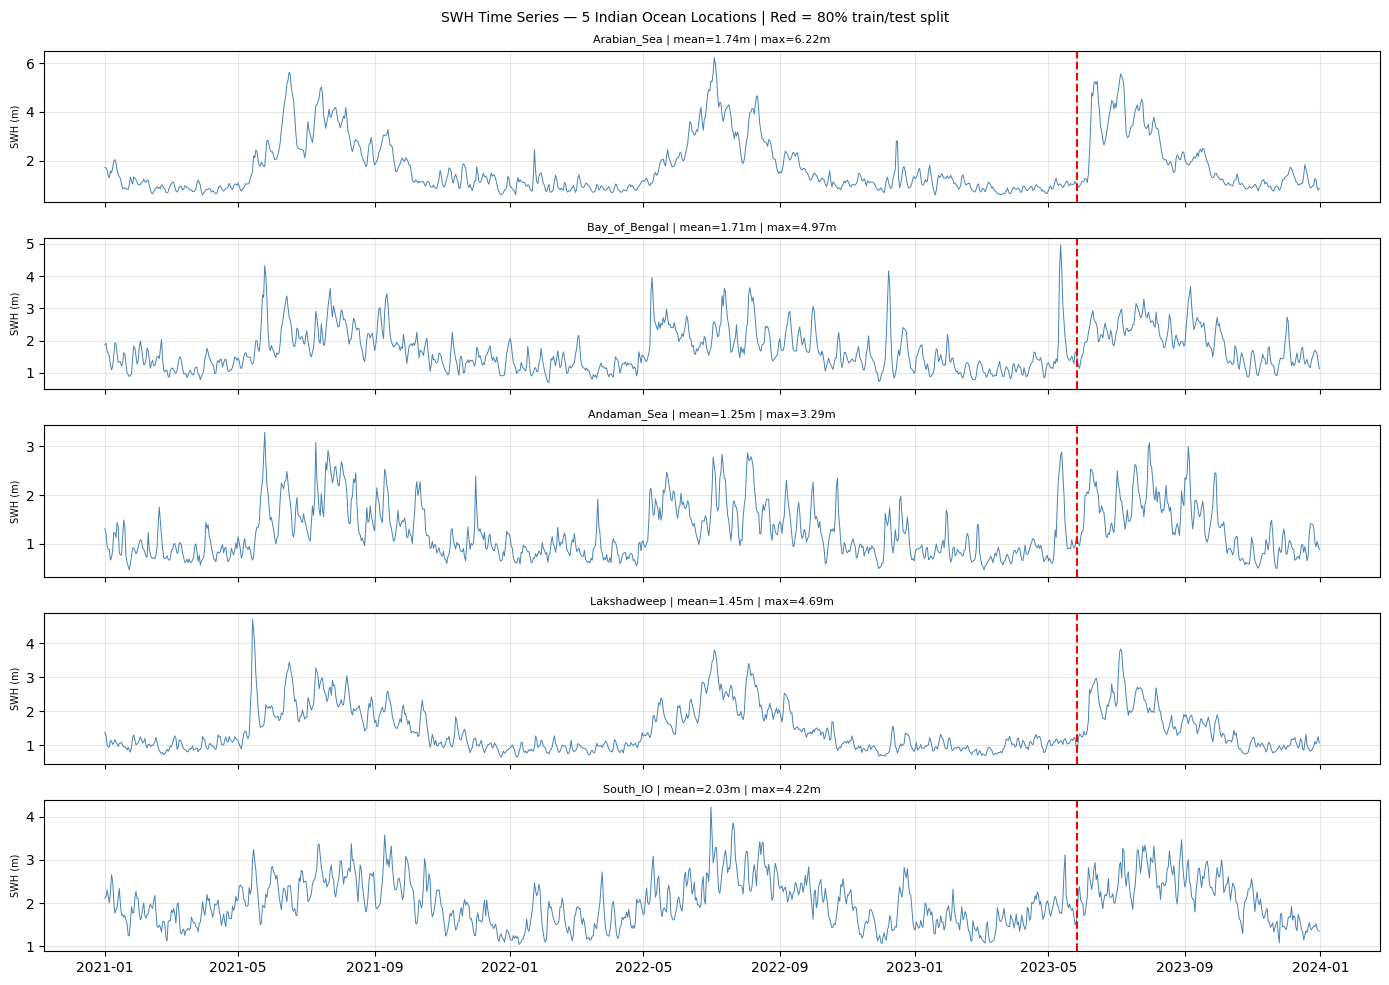

In [2]:
# ── Cell 2: Load SWH Data ────────────────────────────────────
# Same 5 Indian Ocean locations as SLA study (same coordinates,
# same period 2021-2023) — enables direct SLA vs SWH comparison.
LOCATIONS = {
    'Arabian_Sea':   (15.0, 65.0),
    'Bay_of_Bengal': (12.0, 87.0),
    'Andaman_Sea':   (11.0, 95.0),
    'Lakshadweep':   (10.0, 73.0),
    'South_IO':      (-5.0, 75.0),
}

print('Loading SWH dataset...')
ds = xr.open_dataset(DATA_FILE)
ds = ds.resample(time='1D').mean()
times_index = pd.to_datetime(ds['time'].values)

# ── Auto-detect SWH variable name ───────────────────────────
# CMEMS products use different names depending on the product:
# 'VHM0'  → ERA5-based reanalysis / wave model reanalysis
# 'hs'    → some hindcast products
# 'swh'   → alternative naming
SWH_VAR = None
for candidate in ['VHM0', 'hs', 'swh', 'SWH', 'Hs']:
    if candidate in ds.data_vars:
        SWH_VAR = candidate
        break
if SWH_VAR is None:
    print("Available variables:", list(ds.data_vars))
    raise ValueError("Cannot find SWH variable. Set SWH_VAR manually above.")

print(f'SWH variable detected: {SWH_VAR}')
print(f'Period: {times_index[0].date()} to {times_index[-1].date()} ({len(times_index)} days)')
print(f'Grid: lat={float(ds.latitude.min()):.2f} to {float(ds.latitude.max()):.2f}, '
      f'lon={float(ds.longitude.min()):.2f} to {float(ds.longitude.max()):.2f}')

# ── Coverage + NaN check ─────────────────────────────────────
print('\nCoverage check at each location:')
for loc, (lat, lon) in LOCATIONS.items():
    swh = ds[SWH_VAR].sel(latitude=lat, longitude=lon, method='nearest').values.flatten()
    nan_pct = np.isnan(swh).mean() * 100
    valid   = swh[~np.isnan(swh)]
    rng     = f"[{valid.min():.3f}, {valid.max():.3f}]m" if len(valid) > 0 else "ALL NaN"
    flag    = " ⚠️ HIGH NaN" if nan_pct > 20 else " ✓"
    print(f'  {loc:<18} ({lat:.1f}N,{lon:.1f}E) | NaN={nan_pct:.1f}% | range={rng}{flag}')

print()
print('NOTE: SWH > 0 always. NaN means ice-covered or land-masked cells.')
print('If NaN > 20% at a location, consider shifting 1-2 degrees offshore.')

# ── Quick time series plot ────────────────────────────────────
fig, axes = plt.subplots(5, 1, figsize=(14, 10), sharex=True)
for ax, (loc, (lat, lon)) in zip(axes, LOCATIONS.items()):
    swh = ds[SWH_VAR].sel(latitude=lat, longitude=lon, method='nearest').values.flatten()
    ax.plot(times_index, swh, lw=0.7, color='steelblue')
    n_train = int(len(swh)*0.80)
    ax.axvline(times_index[n_train], color='red', lw=1.5, ls='--')
    ax.set_title(f'{loc} | mean={np.nanmean(swh):.2f}m | max={np.nanmax(swh):.2f}m', fontsize=8)
    ax.set_ylabel('SWH (m)', fontsize=7); ax.grid(True, alpha=0.3)
fig.suptitle('SWH Time Series — 5 Indian Ocean Locations | Red = 80% train/test split', fontsize=10)
plt.tight_layout(); plt.show()

In [7]:
# ── Cell 3: Config + All Helpers ─────────────────────────────
TRAIN_SPLIT  = 0.80
SEQ_LEN      = 30     # 30-day lookback (same as SLA)
EPOCHS       = 100
BATCH_SIZE   = 64
LR           = 0.001
PATIENCE     = 20
VAL_SPLIT    = 0.10
SEEDS        = [42, 7, 13, 99, 2025]
TUBE_R       = 0.5
TUBE_DELTA   = 0.01
MIN_WIDTH    = 0.05   # ← SWH: 5 cm minimum width (SLA used 0.005 m)
                      #   SWH varies by metres so minimum is larger
DROPOUT      = 0.2
ALPHA_WIS    = 0.20   # p10/p90 intervals
TARGET_PICP  = 0.95

print(f'SEQ_LEN={SEQ_LEN} | EPOCHS={EPOCHS} | BATCH={BATCH_SIZE} | {len(SEEDS)} seeds')
print(f'Tube: r={TUBE_R}, delta={TUBE_DELTA} | MIN_WIDTH={MIN_WIDTH}m (5cm for SWH)')

# ─── Data splits with SWH-specific NaN handling ───────────────
def get_splits(loc_name):
    lat, lon = LOCATIONS[loc_name]
    swh_raw = ds[SWH_VAR].sel(latitude=lat, longitude=lon, method='nearest').values.flatten()
    # Linear interpolation for gaps ≤ 14 days, then forward-fill
    s = pd.Series(swh_raw, index=times_index).interpolate(method='time', limit=14).ffill().bfill()
    # SWH FLOOR: wave height cannot be negative (unlike SLA)
    s = s.clip(lower=0.0)
    data = s.values

    n = len(data); n_train = int(n * TRAIN_SPLIT); n_test = n - n_train
    scaler  = RobustScaler()
    train_s = scaler.fit_transform(data[:n_train].reshape(-1,1)).flatten()
    test_s  = scaler.transform(data[n_train:].reshape(-1,1)).flatten()
    combined = np.concatenate([train_s, test_s])

    X_tr = np.array([train_s[i:i+SEQ_LEN] for i in range(len(train_s)-SEQ_LEN)])[..., np.newaxis]
    y_tr = np.array([train_s[i+SEQ_LEN]   for i in range(len(train_s)-SEQ_LEN)])
    X_te = np.array([combined[n_train-SEQ_LEN+i:n_train+i] for i in range(n_test)])[..., np.newaxis]
    y_te = np.array([combined[n_train+i] for i in range(n_test)])
    return dict(X_tr=X_tr, y_tr=y_tr, X_te=X_te, y_te=y_te,
                scaler=scaler, n_train=n_train, n_test=n_test, raw=data)

# ─── Loss functions (identical to SLA — MIN_WIDTH handles scale) ──
def build_quantile_loss(scaler, q_lo=0.10, q_hi=0.90):
    min_ws = float(abs(scaler.transform([[MIN_WIDTH]])[0][0] - scaler.transform([[0.0]])[0][0]))
    def loss(yt, yp):
        true = yt[:,0:1]; lo = yp[:,0:1]; hi = yp[:,1:2]
        elo, ehi = true-lo, true-hi
        return (tf.reduce_mean(tf.maximum(q_lo*elo,(q_lo-1)*elo))
              + tf.reduce_mean(tf.maximum(q_hi*ehi,(q_hi-1)*ehi))
              + tf.reduce_mean(tf.nn.relu(lo-hi))
              + tf.reduce_mean(tf.nn.relu(min_ws-(hi-lo))))
    return loss

def build_tube_loss(scaler, r=TUBE_R, delta=TUBE_DELTA):
    min_ws = float(abs(scaler.transform([[MIN_WIDTH]])[0][0] - scaler.transform([[0.0]])[0][0]))
    def loss(yt, yp):
        true = yt[:,0:1]; lo = yp[:,0:1]; hi = yp[:,1:2]
        return (tf.reduce_mean((1-r)*tf.nn.relu(lo-true) + r*tf.nn.relu(true-hi)
                + delta*tf.abs(hi-lo) + tf.nn.relu(lo-hi))
              + tf.reduce_mean(tf.nn.relu(min_ws-(hi-lo))))
    return loss

# ─── Evaluation — SWH FLOOR applied after inverse_transform ──
def evaluate(y_true_s, y_pred_raw, scaler):
    lo_m = scaler.inverse_transform(y_pred_raw[:,0:1]).flatten()
    hi_m = scaler.inverse_transform(y_pred_raw[:,1:2]).flatten()
    y_m  = scaler.inverse_transform(y_true_s.reshape(-1,1)).flatten()
    if np.any(np.isnan(lo_m)) or np.any(np.isnan(hi_m)):
        return np.nan, np.nan, np.nan, np.nan, lo_m, hi_m, y_m
    lo = np.maximum(np.minimum(lo_m, hi_m), 0.0)  # swap + floor at 0
    hi = np.maximum(np.maximum(lo_m, hi_m), 0.0)  # SWH cannot be negative
    picp = float(np.mean((y_m >= lo) & (y_m <= hi))) * 100.0
    mpiw = float(np.mean(hi - lo))
    wis  = float(np.mean((hi-lo)+(2/ALPHA_WIS)*np.maximum(0,lo-y_m)+(2/ALPHA_WIS)*np.maximum(0,y_m-hi)))
    cwc  = mpiw if picp/100 >= TARGET_PICP else mpiw*np.exp(-50*(picp/100-TARGET_PICP))
    return picp, mpiw, wis, cwc, lo, hi, y_m

# ─── Model builder ────────────────────────────────────────────
K = 3   # mixture components

class MDNOutputLayer(layers.Layer):
    def __init__(self, k, **kwargs):
        super().__init__(**kwargs)
        self.k = k
        self.pi_dense    = layers.Dense(k)
        self.mu_dense    = layers.Dense(k)
        self.sigma_dense = layers.Dense(k)
    def call(self, x):
        pi    = tf.nn.softmax(self.pi_dense(x)) + 1e-8
        mu    = self.mu_dense(x)
        sigma = tf.nn.softplus(self.sigma_dense(x)) + 1e-5
        return tf.concat([pi, mu, sigma], axis=-1)

def build_model(seq_len=SEQ_LEN, k=K, dropout=DROPOUT):
    inp = keras.Input(shape=(seq_len,1))
    x   = layers.GRU(64, activation='tanh')(inp)
    x   = layers.Dropout(dropout)(x)
    x   = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    return keras.Model(inp, MDNOutputLayer(k)(x))

def mdn_nll(k=K):
    def loss(yt, yp):
        true=yt[:,0:1]; pi=yp[:,:k]; mu=yp[:,k:2*k]; sig=yp[:,2*k:3*k]
        log_norm=-0.5*tf.square((true-mu)/sig)-tf.math.log(sig)-0.5*tf.cast(tf.math.log(2*np.pi),tf.float32)
        return -tf.reduce_mean(tf.reduce_logsumexp(tf.math.log(pi)+log_norm, axis=1))
    return loss

def mdn_eval(y_pred_raw, scaler, k=K, n_samp=5000, q_lo=0.04, q_hi=0.96):
    pi=y_pred_raw[:,:k]; mu=y_pred_raw[:,k:2*k]; sig=y_pred_raw[:,2*k:3*k]
    pi=pi/pi.sum(axis=1,keepdims=True)
    los,his=[],[]
    for i in range(len(y_pred_raw)):
        idx=np.random.choice(k,size=n_samp,p=pi[i])
        samp=np.random.normal(mu[i,idx],np.abs(sig[i,idx]))
        lo_s=float(np.quantile(samp,q_lo)); hi_s=float(np.quantile(samp,q_hi))
        lo_m=float(scaler.inverse_transform([[lo_s]])[0,0])
        hi_m=float(scaler.inverse_transform([[hi_s]])[0,0])
        los.append(max(0,lo_m)); his.append(max(0,hi_m))   # SWH floor
    return np.array(los), np.array(his)

ARCH = 'MDN-GRU'
print(f'MDN model: K={K} components | q=[0.025,0.975] targeting 95% PI')

print('All helpers defined. Proceed to Cell 4.')

SEQ_LEN=30 | EPOCHS=100 | BATCH=64 | 5 seeds
Tube: r=0.5, delta=0.01 | MIN_WIDTH=0.05m (5cm for SWH)
MDN model: K=3 components | q=[0.025,0.975] targeting 95% PI
All helpers defined. Proceed to Cell 4.


In [8]:
# Cell 4 — MDN Training
all_results=[]; all_preds={}

for loc_name in LOCATIONS:
    print(f'\n{"#"*55}')
    print(f'  MDN-GRU-K{K} @ {loc_name}')
    print(f'{"#"*55}')
    d=get_splits(loc_name)
    lat,lon=LOCATIONS[loc_name]
    y_dup=np.hstack([d['y_tr'].reshape(-1,1),d['y_tr'].reshape(-1,1)])
    all_preds[loc_name]={f'MDN-GRU-K{K}':{}}
    s_picps,s_mpiws,s_wis,s_cwc=[],[],[],[]
    print(f'  Train seqs: {len(d["X_tr"])} | Test pts: {d["n_test"]}')

    for seed in SEEDS:
        tf.random.set_seed(seed); np.random.seed(seed)
        m=build_model(); m.compile(optimizer=keras.optimizers.Adam(LR,clipnorm=1.0),loss=mdn_nll(K))
        cbs=[keras.callbacks.EarlyStopping(patience=PATIENCE,restore_best_weights=True,verbose=0),
             keras.callbacks.ReduceLROnPlateau(factor=0.5,patience=10,min_lr=1e-6,verbose=0)]
        hist=m.fit(d['X_tr'],y_dup,epochs=EPOCHS,batch_size=BATCH_SIZE,
                   validation_split=VAL_SPLIT,callbacks=cbs,verbose=0)
        raw=m.predict(d['X_te'],verbose=0)
        lo_m,hi_m=mdn_eval(raw,d['scaler'])
        y_m=d['scaler'].inverse_transform(d['y_te'].reshape(-1,1)).flatten()
        y_m=np.maximum(y_m,0)
        lo=np.minimum(lo_m,hi_m); hi=np.maximum(lo_m,hi_m)
        picp=float(np.mean((y_m>=lo)&(y_m<=hi)))*100
        mpiw=float(np.mean(hi-lo))
        wis=float(np.mean((hi-lo)+(2/ALPHA_WIS)*np.maximum(0,lo-y_m)+(2/ALPHA_WIS)*np.maximum(0,y_m-hi)))
        cwc=mpiw if picp/100>=TARGET_PICP else mpiw*np.exp(-50*(picp/100-TARGET_PICP))
        s_picps.append(picp);s_mpiws.append(mpiw);s_wis.append(wis);s_cwc.append(cwc)
        all_preds[loc_name][f'MDN-GRU-K{K}'][seed]=(lo,hi,y_m)
        ep=len(hist.history['loss'])
        print(f'    seed={seed:4d} | PICP={picp:.1f}% | MPIW={mpiw:.4f}m | WIS={wis:.4f} | ep={ep}')

    avg_p=np.nanmean(s_picps);std_p=np.nanstd(s_picps)
    avg_m=np.nanmean(s_mpiws);std_m=np.nanstd(s_mpiws)
    avg_w=np.nanmean(s_wis);std_w=np.nanstd(s_wis)
    avg_c=np.nanmean(s_cwc);std_c=np.nanstd(s_cwc)
    n_v=sum(1 for p in s_picps if not np.isnan(p))
    print(f'  PICP={avg_p:.1f}+/-{std_p:.1f}%  MPIW={avg_m:.4f}m  WIS={avg_w:.4f}  [{n_v}/{len(SEEDS)}]')
    all_results.append(dict(
        location=loc_name,lat=lat,lon=lon,arch='MDN-GRU',loss='NLL-Mixture',model=f'MDN-GRU-K{K}',
        q_lo=0.025,q_hi=0.975,r=None,delta=None,
        avg_picp=avg_p,std_picp=std_p,avg_mpiw=avg_m,std_mpiw=std_m,
        avg_wis=avg_w,std_wis=std_w,avg_cwc=avg_c,std_cwc=std_c,
        n_seeds=len(SEEDS),n_valid_seeds=n_v,
        n_train_seqs=len(d['X_tr']),n_test_pts=d['n_test'],seq_len=SEQ_LEN,k_components=K))

df=pd.DataFrame(all_results)
csv_path=os.path.join(SAVE_DIR,'results_MDN_SWH.csv')
df.to_csv(csv_path,index=False)
print(f'\nSaved: {csv_path}')
print(df[['location','model','avg_picp','std_picp','avg_mpiw','avg_wis','avg_cwc']].to_string(index=False))


#######################################################
  MDN-GRU-K3 @ Arabian_Sea
#######################################################
  Train seqs: 846 | Test pts: 219
    seed=  42 | PICP=94.5% | MPIW=0.7414m | WIS=0.8160 | ep=82
    seed=   7 | PICP=95.4% | MPIW=0.7671m | WIS=0.8326 | ep=54
    seed=  13 | PICP=96.3% | MPIW=0.7519m | WIS=0.8111 | ep=71
    seed=  99 | PICP=95.9% | MPIW=0.8227m | WIS=0.8905 | ep=53
    seed=2025 | PICP=96.3% | MPIW=0.7262m | WIS=0.7930 | ep=100
  PICP=95.7+/-0.7%  MPIW=0.7618m  WIS=0.8287  [5/5]

#######################################################
  MDN-GRU-K3 @ Bay_of_Bengal
#######################################################
  Train seqs: 846 | Test pts: 219
    seed=  42 | PICP=95.0% | MPIW=0.7786m | WIS=0.8015 | ep=100
    seed=   7 | PICP=96.3% | MPIW=0.7674m | WIS=0.7942 | ep=93
    seed=  13 | PICP=96.8% | MPIW=0.8101m | WIS=0.8287 | ep=73
    seed=  99 | PICP=95.9% | MPIW=0.7908m | WIS=0.8148 | ep=100
    seed=2025 | PICP=95.9% |

Generating plots...


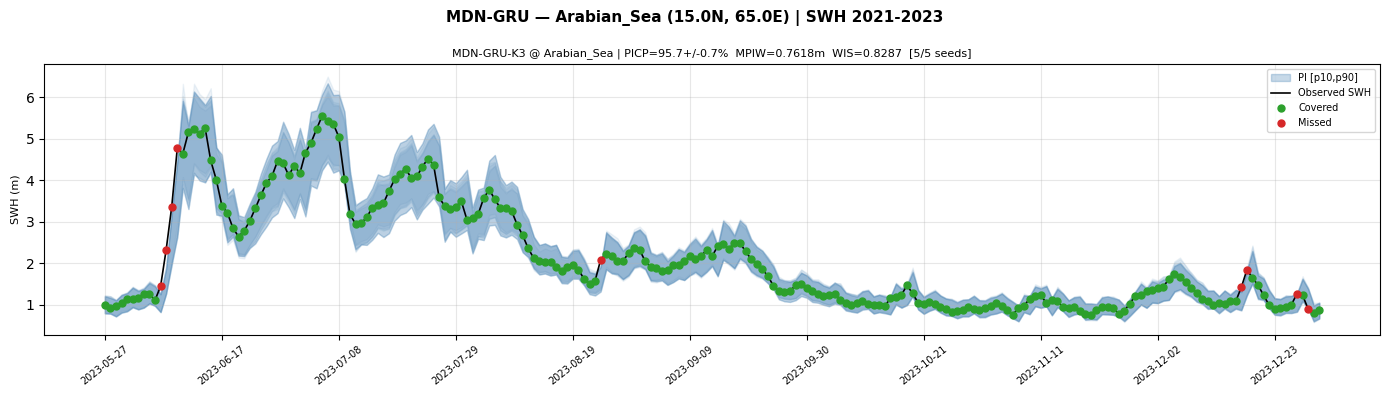

  Saved: c:\Users\DA IICT K\Desktop\BMP_files\SWH_codes\results_SWH/plot_MDN-GRU_Arabian_Sea_SWH.png


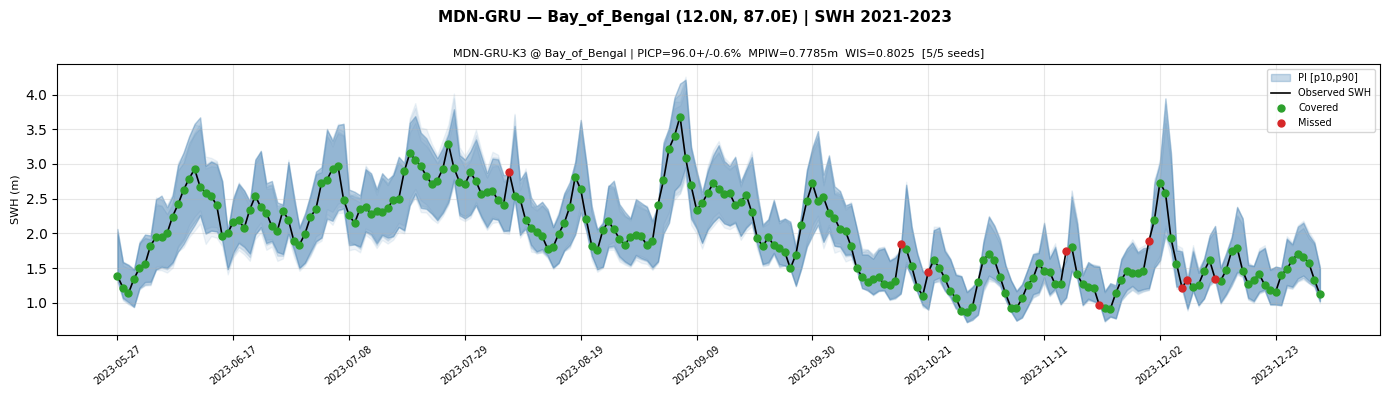

  Saved: c:\Users\DA IICT K\Desktop\BMP_files\SWH_codes\results_SWH/plot_MDN-GRU_Bay_of_Bengal_SWH.png


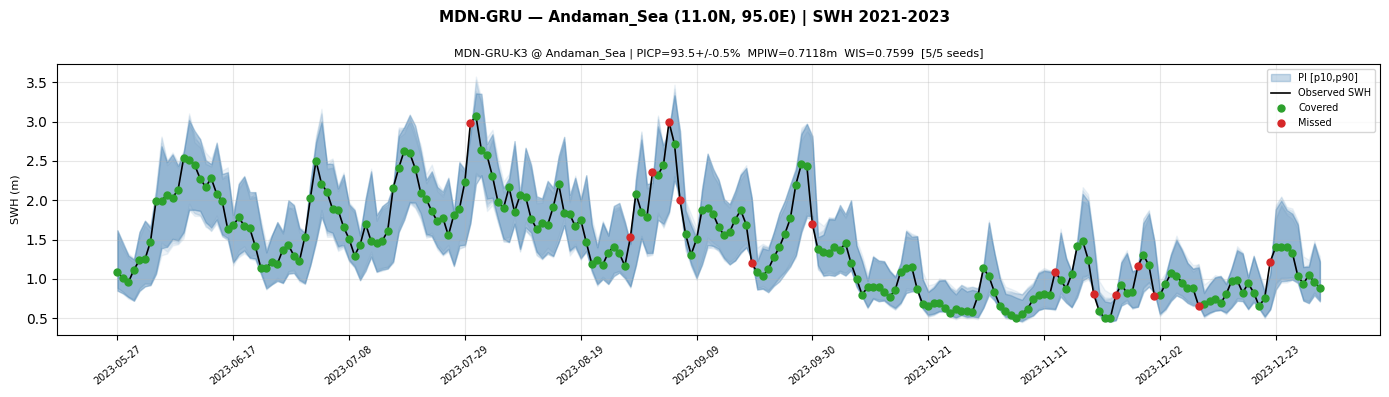

  Saved: c:\Users\DA IICT K\Desktop\BMP_files\SWH_codes\results_SWH/plot_MDN-GRU_Andaman_Sea_SWH.png


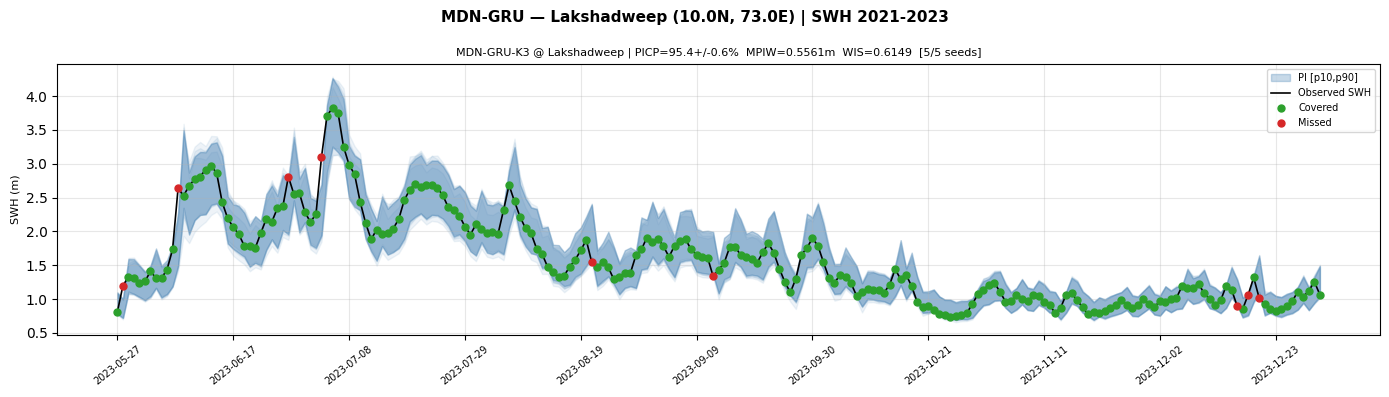

  Saved: c:\Users\DA IICT K\Desktop\BMP_files\SWH_codes\results_SWH/plot_MDN-GRU_Lakshadweep_SWH.png


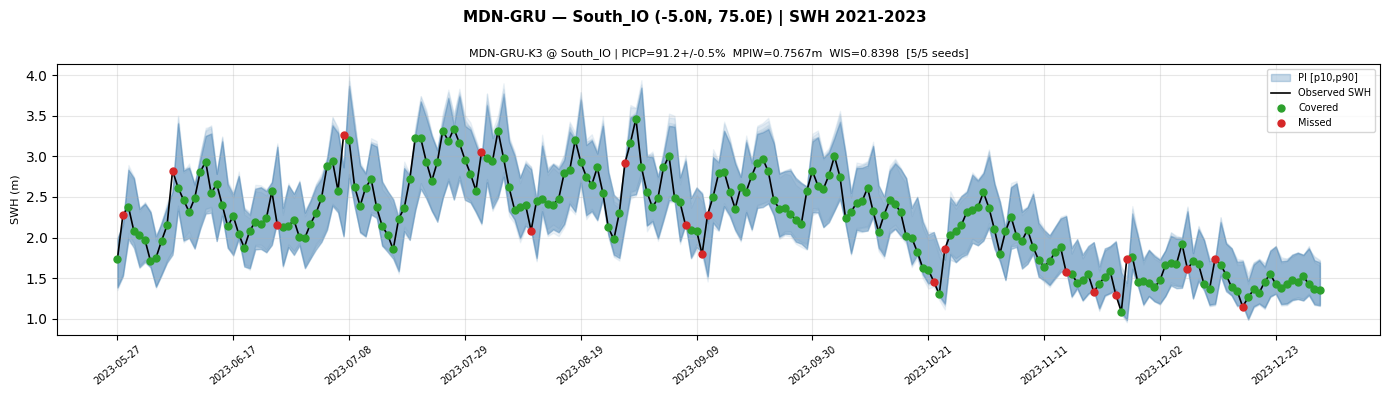

  Saved: c:\Users\DA IICT K\Desktop\BMP_files\SWH_codes\results_SWH/plot_MDN-GRU_South_IO_SWH.png


In [9]:
# ── Cell 5: Visualisation ────────────────────────────────────
print('Generating plots...')
for loc_name in LOCATIONS:
    d   = get_splits(loc_name)
    lat, lon = LOCATIONS[loc_name]
    sub = df[df['location']==loc_name]
    n_rows = len(sub)
    fig, axes = plt.subplots(n_rows, 1, figsize=(14, 4*n_rows))
    if n_rows==1: axes=[axes]
    te_times = times_index[d['n_train']:]
    x_ax = range(len(te_times))
    step = max(1, len(te_times)//10)

    for ax, (_, row) in zip(axes, sub.iterrows()):
        mid = row['model']
        pd_ = all_preds.get(loc_name, {}).get(mid, {})
        y_m = None
        for seed, (lo,hi,ym) in pd_.items():
            if y_m is None: y_m = ym
            if np.any(np.isnan(lo)): continue
            ax.fill_between(x_ax, lo, hi, alpha=0.09, color='steelblue')
        cands = [(abs(np.mean((ym>=lo)&(ym<=hi))*100 - row['avg_picp']), seed)
                 for seed,(lo,hi,ym) in pd_.items() if not np.any(np.isnan(lo))]
        if cands:
            best = sorted(cands)[0][1]
            lo_b,hi_b,y_m = pd_[best]
            ax.fill_between(x_ax, lo_b, hi_b, alpha=0.30, color='steelblue', label='PI [p10,p90]')
            covered = (y_m >= lo_b) & (y_m <= hi_b)
            ax.plot(x_ax, y_m, 'k-', lw=1.2, label='Observed SWH')
            ax.scatter(np.where(covered)[0],  y_m[covered],  color='#2ca02c', s=25, zorder=5, label='Covered')
            ax.scatter(np.where(~covered)[0], y_m[~covered], color='#d62728', s=25, zorder=5, label='Missed')
        ax.set_xticks(list(x_ax)[::step])
        ax.set_xticklabels([te_times[i].strftime('%Y-%m-%d') for i in range(0,len(te_times),step)],
                           rotation=38, fontsize=7)
        ax.set_ylabel('SWH (m)', fontsize=8)
        ax.set_title(f'{mid} @ {loc_name} | PICP={row["avg_picp"]:.1f}+/-{row["std_picp"]:.1f}%  '
                     f'MPIW={row["avg_mpiw"]:.4f}m  WIS={row["avg_wis"]:.4f}  [{row["n_valid_seeds"]}/{row["n_seeds"]} seeds]',
                     fontsize=8)
        ax.legend(fontsize=7, loc='upper right'); ax.grid(alpha=0.3)
    fig.suptitle(f'{ARCH} — {loc_name} ({lat}N, {lon}E) | SWH 2021-2023', fontsize=11, fontweight='bold')
    plt.tight_layout()
    fp = os.path.join(SAVE_DIR, f'plot_{ARCH}_{loc_name}_SWH.png')
    plt.savefig(fp, dpi=110, bbox_inches='tight'); plt.show()
    print(f'  Saved: {fp}')

In [10]:
# ── Cell 6: Per-arch summary table ──────────────────────────
print(f'\n{"="*95}')
print(f'  {ARCH} — SWH RESULTS')
print(f'{"="*95}')
print(f'  {"Location":<18} {"Model":<24} {"PICP%":>7} {"+/-":>5} {"MPIW(m)":>9} {"+/-":>8} '
      f'{"WIS":>9} {"CWC":>9} {"Valid":>6}')
print(f'  {"-"*95}')
for _, r in df.sort_values(["location","model"]).iterrows():
    r_s = f"{r['r']:.1f}"    if pd.notna(r['r'])     else "  --"
    d_s = f"{r['delta']:.3f}" if pd.notna(r['delta']) else "    --"
    print(f'  {r["location"]:<18} {r["model"]:<24} '
          f'{r["avg_picp"]:7.1f} {r["std_picp"]:5.1f} '
          f'{r["avg_mpiw"]:9.4f} {r["std_mpiw"]:8.4f} '
          f'{r["avg_wis"]:9.4f} {r["avg_cwc"]:9.4f} '
          f'{r["n_valid_seeds"]:>3}/{r["n_seeds"]}')


  MDN-GRU — SWH RESULTS
  Location           Model                      PICP%   +/-   MPIW(m)      +/-       WIS       CWC  Valid
  -----------------------------------------------------------------------------------------------
  Andaman_Sea        MDN-GRU-K3                  93.5   0.5    0.7118   0.0111    0.7599    1.5407   5/5
  Arabian_Sea        MDN-GRU-K3                  95.7   0.7    0.7618   0.0332    0.8287    0.8020   5/5
  Bay_of_Bengal      MDN-GRU-K3                  96.0   0.6    0.7785   0.0217    0.8025    0.7803   5/5
  Lakshadweep        MDN-GRU-K3                  95.4   0.6    0.5561   0.0088    0.6149    0.5599   5/5
  South_IO           MDN-GRU-K3                  91.2   0.5    0.7567   0.0088    0.8398    5.1254   5/5
